                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 131ms/step - accuracy: 0.5151 - loss: 0.6984 - val_accuracy: 0.5638 - val_loss: 0.6744
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - accuracy: 0.5979 - loss: 0.6560 - val_accuracy: 0.5845 - val_loss: 0.6562
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 114ms/step - accuracy: 0.6765 - loss: 0.5638 - val_accuracy: 0.5558 - val_loss: 0.6885
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 30s 118ms/step - accuracy: 0.7322 - loss: 0.4574 - val_accuracy: 0.5536 - val_loss: 0.7776
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 139ms/step - accuracy: 0.7556 - loss: 0.3916 - val_accuracy: 0.5670 - val_loss: 0.8086
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5659 - loss: 0.8097

Test Accuracy: 0.5714
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


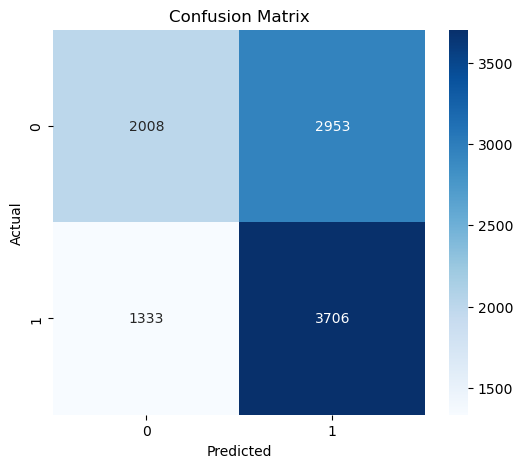


Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.40      0.48      4961
           1       0.56      0.74      0.63      5039

    accuracy                           0.57     10000
   macro avg       0.58      0.57      0.56     10000
weighted avg       0.58      0.57      0.56     10000



In [1]:
# -----------------------------
# IMPORT LIBRARIES
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# -----------------------------
# LOAD DATASET (YOUR FILE)
# -----------------------------
df = pd.read_csv('a1_IMDB_Dataset.csv')

print(df.head())

# -----------------------------
# DATA PREPROCESSING
# -----------------------------

# Encode labels (positive=1, negative=0)
encoder = LabelEncoder()
df['sentiment'] = encoder.fit_transform(df['sentiment'])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42
)

# Tokenization
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
max_len = 200
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# -----------------------------
# BUILD RNN MODEL
# -----------------------------
model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=vocab_size, output_dim=128))

# Simple RNN Layer
model.add(SimpleRNN(64))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# Compile
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# -----------------------------
# TRAIN MODEL
# -----------------------------
history = model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

# -----------------------------
# EVALUATION
# -----------------------------
loss, acc = model.evaluate(X_test_pad, y_test)
print(f"\nTest Accuracy: {acc:.4f}")

# Predictions
y_pred = model.predict(X_test_pad)
y_pred_classes = (y_pred > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))